# 04 — NDVI (Sentinel-2 via Google Earth Engine)

Pull a Sentinel-2 growing-season NDVI composite for the Emerald Triangle
and compute median NDVI per hex cell.

**Why growing season only:** Cannabis peaks in canopy density July–October.
A summer composite captures the vegetation signal when cultivation shows up
most distinctly vs. background forest/shrub.

**Requires:** authenticated Earth Engine session.
Run `earthengine authenticate` in a terminal if not already done.

**Outputs:**
- `data/raw/ndvi_median.tif` — median NDVI raster (10m, WGS84 → reprojected to UTM 10N)
- `data/processed/ndvi_features.pkl` — per-cell NDVI median

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterstats import zonal_stats
import matplotlib.pyplot as plt

RAW  = Path('../data/raw')
PROC = Path('../data/processed')
IMG  = Path('../img')

NDVI_TIF = RAW / 'ndvi_median.tif'

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## 1. Authenticate and initialize Earth Engine

In [2]:
import ee

try:
    ee.Initialize(project='ee-simonhansedasi')  # replace with your GEE project ID
    print('Earth Engine initialized')
except Exception as e:
    print(f'EE init failed: {e}')
    print('Run:  earthengine authenticate')
    print('Then restart the kernel and re-run this cell.')
    raise

/home/simonhans/anaconda3/lib/python3.7/site-packages/google/auth/crypt/_cryptography_rsa.py:22: CryptographyDeprecationWarning: Python 3.7 is no longer supported by the Python core team and support for it is deprecated in cryptography. The next release of cryptography will remove support for Python 3.7.
  import cryptography.exceptions


Earth Engine initialized


## 2. Define study area and pull Sentinel-2 composite

In [3]:
study_area = gpd.read_file(RAW / 'study_area.gpkg').to_crs('EPSG:4326')
bounds = study_area.total_bounds   # xmin, ymin, xmax, ymax

# GEE geometry from bounding box
roi = ee.Geometry.BBox(
    float(bounds[0]), float(bounds[1]),
    float(bounds[2]), float(bounds[3])
)

# Sentinel-2 Surface Reflectance, growing season composite 2022–2024
# July–October captures cannabis canopy peak
s2 = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(roi)
    .filter(ee.Filter.calendarRange(7, 10, 'month'))   # July–October
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .filterDate('2022-01-01', '2024-12-31')
)

print(f'Images in collection: {s2.size().getInfo()}')

Images in collection: 1223


In [4]:
def add_ndvi(img):
    ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return img.addBands(ndvi)

ndvi_median = (
    s2.map(add_ndvi)
    .select('NDVI')
    .median()
    .clip(roi)
)

print('NDVI composite ready')
print('Projection:', ndvi_median.projection().getInfo())

NDVI composite ready
Projection: {'type': 'Projection', 'crs': 'EPSG:4326', 'transform': [1, 0, 0, 0, 1, 0]}


## 3. Export to Google Drive, then download

GEE cannot stream large rasters directly. Export to Drive, download, then continue.
If the study area is small enough, `getDownloadURL` works without Drive.

In [5]:
# # Try direct download first (works for smaller areas / lower resolution)
# # If this hits the GEE size limit, use the Drive export in the next cell instead.

# url = ndvi_median.getDownloadURL({
#     'region':      roi,
#     'scale':       30,         # 30m matches DEM resolution; native S2 is 10m
#     'format':      'GEO_TIFF',
#     'crs':         'EPSG:4326',
# })
# print('Download URL obtained — downloading...')

# import requests
# r = requests.get(url, timeout=600, stream=True)
# r.raise_for_status()
# with open(NDVI_TIF, 'wb') as f:
#     for chunk in r.iter_content(1 << 20):
#         f.write(chunk)
# print(f'Saved {NDVI_TIF}  ({NDVI_TIF.stat().st_size / 1e6:.1f} MB)')

In [6]:
# # FALLBACK: if cell above hits a GEE size error, export to Drive instead.
# # Uncomment, run, wait for task to complete, download the .tif from Drive manually
# # to data/raw/ndvi_median.tif, then skip to cell c6.

# task = ee.batch.Export.image.toDrive(
#     image=ndvi_median,
#     description='ndvi_emerald_median',
#     folder='GeoGastronomy',
#     fileNamePrefix='ndvi_median',
#     region=roi,
#     scale=30,
#     crs='EPSG:4326',
#     maxPixels=1e9,
# )
# task.start()
# print(f'Export task started: {task.id}')
# print('Monitor at: https://code.earthengine.google.com/tasks')

## 4. Reproject to UTM 10N and compute zonal stats

In [7]:
NDVI_UTM = RAW / 'ndvi_median_utm.tif'

if not NDVI_UTM.exists():
    import subprocess
    print('Reprojecting NDVI to UTM 10N...')
    study_utm = gpd.read_file(RAW / 'study_area.gpkg')
    b = study_utm.total_bounds
    subprocess.run([
        'gdalwarp',
        '-t_srs', 'EPSG:32610',
        '-te', str(b[0]), str(b[1]), str(b[2]), str(b[3]),
        '-tr', '30', '30',
        '-r',  'bilinear',
        '-co', 'COMPRESS=LZW',
        str(NDVI_TIF), str(NDVI_UTM),
    ], check=True, capture_output=True)
    print(f'Saved {NDVI_UTM}')
else:
    print('ndvi_median_utm.tif cached')

with rasterio.open(NDVI_UTM) as src:
    print(f'Shape: {src.shape}, CRS: {src.crs}')

Reprojecting NDVI to UTM 10N...
Saved ../data/raw/ndvi_median_utm.tif
Shape: (10161, 5874), CRS: EPSG:32610


In [8]:
hex_grid = gpd.read_file(RAW / 'hex_grid.gpkg')

print('Running NDVI zonal stats...')
ndvi_stats = zonal_stats(
    hex_grid, str(NDVI_UTM),
    stats=['mean', 'std', 'min', 'max'],
    nodata=-9999, all_touched=False,
)
ndvi_df = pd.DataFrame(ndvi_stats)
ndvi_df.columns = ['ndvi_' + c for c in ndvi_df.columns]
ndvi_df.insert(0, 'cell_id', hex_grid['cell_id'])

n_valid = ndvi_df['ndvi_mean'].notna().sum()
print(f'Cells with NDVI: {n_valid:,} / {len(ndvi_df):,}')
print(ndvi_df['ndvi_mean'].describe().round(3))

Running NDVI zonal stats...
Cells with NDVI: 8,923 / 8,923
count    8923.000
mean        0.614
std         0.265
min        -0.440
25%         0.519
50%         0.691
75%         0.811
max         0.898
Name: ndvi_mean, dtype: float64


## 5. Map and save

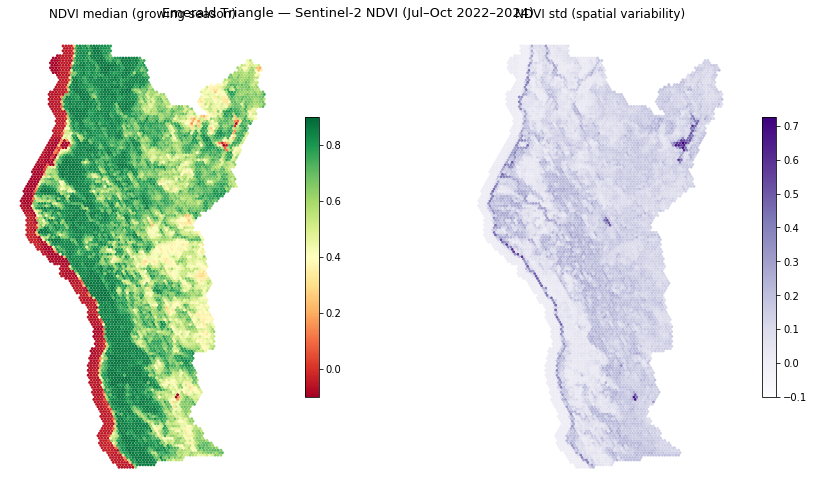

In [9]:
hex_feats = hex_grid.merge(ndvi_df, on='cell_id')

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, col, title, cmap in zip(
    axes,
    ['ndvi_mean', 'ndvi_std'],
    ['NDVI median (growing season)', 'NDVI std (spatial variability)'],
    ['RdYlGn', 'Purples'],
):
    hex_feats.plot(column=col, ax=ax, cmap=cmap, legend=True,
                   legend_kwds={'shrink': 0.6}, linewidth=0,
                   vmin=-0.1, vmax=0.9 if 'mean' in col else None)
    ax.set_title(title, fontsize=12)
    ax.set_axis_off()

plt.suptitle('Emerald Triangle — Sentinel-2 NDVI (Jul–Oct 2022–2024)', fontsize=13)
plt.tight_layout()
plt.savefig('../img/04_ndvi.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
out = PROC / 'ndvi_features.pkl'
ndvi_df.to_pickle(out)
print(f'Saved {out}')
print(f'Shape: {ndvi_df.shape}')
print()
print('Next: 05_climate.ipynb — PRISM climate variables')

Saved ../data/processed/ndvi_features.pkl
Shape: (8923, 5)

Next: 05_climate.ipynb — PRISM climate variables
